# World Bank Linear Algebra Analysis

### Part 1
Build a country × year unemployment matrix and analyses:

- missingness structure
- rank
- REF / RREF on a subset
- correlation between years
- country similarity
- PCA on unemployment trajectories

### Part 2
Builds a country × feature matrix using:

- unemployment
- inflation
- GDP growth
- life expectancy
- population growth

Then analyse:

- missingness
- rank
- feature correlation
- country similarity
- PCA

## Step 1: Import project functions


In [3]:
import src.api_client as api_client
print(api_client.__file__)

/Users/tendaisibanda/Documents/Github Projects/worldbank_unemployment_linear_algebra_project/src/api_client.py


In [4]:
from src.config import START_YEAR, END_YEAR, INDICATORS
from src.api_client import fetch_indicator_data, fetch_country_metadata
from src.data_processing import (
    raw_to_dataframe,
    country_metadata_to_dataframe,
    merge_country_metadata,
    remove_aggregate_entities,
    build_country_year_matrix
)
from src.matrix_analysis import (
    inspect_missingness,
    compute_rank,
    compute_ref_rref,
    compute_column_correlation,
    compute_country_similarity,
    run_pca,
)

## Step 2: Fetch unemployment data

### Why this is done
I will start with one indicator "unemployment" to help me assess data and establish clear the matrix reasoning. This shoudl extract a raw JSON result from the World Bank API for unemployment.

In [5]:
# Fetch raw unemployment data from the World Bank API
raw_unemployment = fetch_indicator_data(
    INDICATORS["unemployment"],
    START_YEAR,
    END_YEAR
)

print("Raw rows fetched:", len(raw_unemployment))
print("\nFirst raw record:")
print(raw_unemployment[0])

Fetched 3990 raw rows for SL.UEM.TOTL.ZS
Raw rows fetched: 3990

First raw record:
{'indicator': {'id': 'SL.UEM.TOTL.ZS', 'value': 'Unemployment, total (% of total labor force) (modeled ILO estimate)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2024', 'value': 7.57169749274654, 'unit': '', 'obs_status': '', 'decimal': 1}


## Step 3: Convert raw data into DataFrame

### Why this is done
The API returns nested JSON, so convert it into a DataFrame will make it easier to inspect and manipulate.

In [6]:
df_unemployment_raw = raw_to_dataframe(raw_unemployment, "unemployment_rate")

print("\nIndicator DataFrame before metadata merge:")
print(df_unemployment_raw.head())
print(df_unemployment_raw.shape)


Indicator DataFrame before metadata merge:
                       country country_code  year  unemployment_rate  \
0  Africa Eastern and Southern          AFE  2024           7.571697   
1  Africa Eastern and Southern          AFE  2023           7.676548   
2  Africa Eastern and Southern          AFE  2022           7.869470   
3  Africa Eastern and Southern          AFE  2021           8.407412   
4  Africa Eastern and Southern          AFE  2020           7.974302   

   indicator_code                                     indicator_name  
0  SL.UEM.TOTL.ZS  Unemployment, total (% of total labor force) (...  
1  SL.UEM.TOTL.ZS  Unemployment, total (% of total labor force) (...  
2  SL.UEM.TOTL.ZS  Unemployment, total (% of total labor force) (...  
3  SL.UEM.TOTL.ZS  Unemployment, total (% of total labor force) (...  
4  SL.UEM.TOTL.ZS  Unemployment, total (% of total labor force) (...  
(3915, 6)


### Step 3.1: Fetch Country Metadata

In [7]:
raw_country_metadata = fetch_country_metadata()
df_country_metadata = country_metadata_to_dataframe(raw_country_metadata)

print("\nCountry metadata sample:")
print(df_country_metadata.head())
print(df_country_metadata.shape)

Fetched 296 country metadata rows

Country metadata sample:
  country_code              wb_country_name  \
0          ABW                        Aruba   
1          AFE  Africa Eastern and Southern   
2          AFG                  Afghanistan   
3          AFR                       Africa   
4          AFW   Africa Western and Central   

                                              region income_level  \
0                         Latin America & Caribbean   High income   
1                                         Aggregates   Aggregates   
2  Middle East, North Africa, Afghanistan & Pakistan   Low income   
3                                         Aggregates   Aggregates   
4                                         Aggregates   Aggregates   

     lending_type  
0  Not classified  
1      Aggregates  
2             IDA  
3      Aggregates  
4      Aggregates  
(296, 5)


### Step 3.2: Merge metadata into indicator data

In [8]:
df_unemployment_with_meta = merge_country_metadata(df_unemployment_raw, df_country_metadata)

print("\nDataFrame after metadata merge:")
print(df_unemployment_with_meta.head(20))
print(df_unemployment_with_meta.shape)


DataFrame after metadata merge:
                        country country_code  year  unemployment_rate  \
0   Africa Eastern and Southern          AFE  2024           7.571697   
1   Africa Eastern and Southern          AFE  2023           7.676548   
2   Africa Eastern and Southern          AFE  2022           7.869470   
3   Africa Eastern and Southern          AFE  2021           8.407412   
4   Africa Eastern and Southern          AFE  2020           7.974302   
5   Africa Eastern and Southern          AFE  2019           7.459106   
6   Africa Eastern and Southern          AFE  2018           7.244843   
7   Africa Eastern and Southern          AFE  2017           7.214915   
8   Africa Eastern and Southern          AFE  2016           7.074429   
9   Africa Eastern and Southern          AFE  2015           6.930941   
10  Africa Eastern and Southern          AFE  2014           6.862429   
11  Africa Eastern and Southern          AFE  2013           6.889722   
12  Africa Eastern

### Step 3.3: Inspect aggregate rows before filtering

In [9]:
aggregate_rows_before = df_unemployment_with_meta[
    df_unemployment_with_meta["region"] == "Aggregates"
]

print("\nAggregate rows before filtering:", len(aggregate_rows_before))
print("\nSample aggregate entities before filtering:")
print(
    aggregate_rows_before[["country", "country_code", "region"]]
    .drop_duplicates()
    .sort_values("country")
    .head(30)
)


Aggregate rows before filtering: 660

Sample aggregate entities before filtering:
                                               country country_code  \
0                          Africa Eastern and Southern          AFE   
15                          Africa Western and Central          AFW   
30                                          Arab World          ARB   
45                              Caribbean small states          CSS   
60                      Central Europe and the Baltics          CEB   
75                          Early-demographic dividend          EAR   
90                                 East Asia & Pacific          EAS   
120         East Asia & Pacific (IDA & IBRD countries)          TEA   
105        East Asia & Pacific (excluding high income)          EAP   
135                                          Euro area          EMU   
150                              Europe & Central Asia          ECS   
180       Europe & Central Asia (IDA & IBRD countries)          T

### Step 3.4: Remove aggregate entities

In [10]:
df_unemployment = remove_aggregate_entities(df_unemployment_with_meta)

# Step 7: Sort final cleaned data
df_unemployment = df_unemployment.sort_values(
    ["country_code", "year"]
).reset_index(drop=True)

print("\nCleaned unemployment DataFrame:")
print(df_unemployment.head())
print(df_unemployment.tail())
print(df_unemployment.shape)
print(df_unemployment.dtypes)

Removed 660 aggregate rows: Africa Eastern and Southern, Africa Western and Central, Arab World, Caribbean small states, Central Europe and the Baltics, Early-demographic dividend, East Asia & Pacific, East Asia & Pacific (IDA & IBRD countries), East Asia & Pacific (excluding high income), Euro area, Europe & Central Asia, Europe & Central Asia (IDA & IBRD countries), Europe & Central Asia (excluding high income), European Union, Fragile and conflict affected situations, Heavily indebted poor countries (HIPC), IBRD only, IDA & IBRD total, IDA blend, IDA only
... and 24 more.

Cleaned unemployment DataFrame:
  country country_code  year  unemployment_rate  indicator_code  \
0   Aruba          ABW  2010                NaN  SL.UEM.TOTL.ZS   
1   Aruba          ABW  2011                NaN  SL.UEM.TOTL.ZS   
2   Aruba          ABW  2012                NaN  SL.UEM.TOTL.ZS   
3   Aruba          ABW  2013                NaN  SL.UEM.TOTL.ZS   
4   Aruba          ABW  2014                NaN  S

### Step 3.5: Confirm aggregates are gone

In [11]:
aggregate_rows_after = df_unemployment[df_unemployment["region"] == "Aggregates"]

print("\nAggregate rows after filtering:", len(aggregate_rows_after))



Aggregate rows after filtering: 0


### Step 3.6: Check the cleaned DataFrame

In [12]:
print("Before filtering:", df_unemployment_with_meta.shape)
print("After filtering:", df_unemployment.shape)

removed_count = len(df_unemployment_with_meta) - len(df_unemployment)
print("Rows removed:", removed_count)

print("Cleaned DF shape:", df_unemployment.shape)
print(df_unemployment.head(20))
print(df_unemployment.tail(20))

Before filtering: (3915, 10)
After filtering: (3255, 10)
Rows removed: 660
Cleaned DF shape: (3255, 10)
        country country_code  year  unemployment_rate  indicator_code  \
0         Aruba          ABW  2010                NaN  SL.UEM.TOTL.ZS   
1         Aruba          ABW  2011                NaN  SL.UEM.TOTL.ZS   
2         Aruba          ABW  2012                NaN  SL.UEM.TOTL.ZS   
3         Aruba          ABW  2013                NaN  SL.UEM.TOTL.ZS   
4         Aruba          ABW  2014                NaN  SL.UEM.TOTL.ZS   
5         Aruba          ABW  2015                NaN  SL.UEM.TOTL.ZS   
6         Aruba          ABW  2016                NaN  SL.UEM.TOTL.ZS   
7         Aruba          ABW  2017                NaN  SL.UEM.TOTL.ZS   
8         Aruba          ABW  2018                NaN  SL.UEM.TOTL.ZS   
9         Aruba          ABW  2019                NaN  SL.UEM.TOTL.ZS   
10        Aruba          ABW  2020                NaN  SL.UEM.TOTL.ZS   
11        Aruba     

## Step 4: Create Country lookup map

In [13]:
country_map = df_unemployment[['country_code', 'country']].drop_duplicates()
country_map = country_map.set_index('country_code')['country']

## Step 5: Build the country × year unemployment matrix

### Why this is done
Creating a matrix will help me apply linear algebra skills for  data analysis.

In [14]:
unemployment_matrix = build_country_year_matrix(df_unemployment, "unemployment_rate")

print(unemployment_matrix.head())
print(unemployment_matrix.shape)

year            2010    2011    2012    2013    2014    2015    2016    2017  \
country_code                                                                   
ABW              NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
AFG            7.809   7.830   7.875   7.921   7.915   9.032  10.116  11.184   
AGO           16.595  16.770  16.539  16.464  16.372  16.472  16.572  16.617   
ALB           14.086  13.481  13.376  15.866  18.055  17.193  15.418  13.616   
AND              NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

year            2018    2019    2020    2021    2022    2023    2024  
country_code                                                          
ABW              NaN     NaN     NaN     NaN     NaN     NaN     NaN  
AFG           11.192  11.187  11.710  12.006  14.100  14.008  13.687  
AGO           16.602  16.497  16.696  15.799  14.124  14.051  14.020  
ALB           12.304  11.466  11.639  11.474  10.785  10.669  10.689  
AND          

## Step 6: Assess missing data

In [15]:
missing_by_country, missing_by_year = inspect_missingness(unemployment_matrix)
missing_by_country_named = missing_by_country.rename(index=country_map)

print("Missing by year:")
print(missing_by_year)

print("\nTop missing countries:")
print(missing_by_country_named.head(10))


Missing by year:
year
2024    35
2023    33
2022    31
2010    30
2011    30
2012    30
2013    30
2014    30
2015    30
2016    30
2017    30
2018    30
2019    30
2020    30
2021    30
dtype: int64

Top missing countries:
country_code
Aruba                       15
Kiribati                    15
Marshall Islands            15
Monaco                      15
St. Martin (French part)    15
Liechtenstein               15
St. Kitts and Nevis         15
Bermuda                     15
Isle of Man                 15
Curacao                     15
dtype: int64


### Step 6.1 Create data frame with countries missing by year

In [16]:
missing_countries_by_year = {}

for year in unemployment_matrix.columns:
    missing_mask = unemployment_matrix[year].isna()
    missing_codes = unemployment_matrix.index[missing_mask].tolist()

    missing_names = [
        country_map.get(code, code)
        for code in missing_codes
    ]

    missing_countries_by_year[year] = sorted(missing_names)

print("Years captured:", len(missing_countries_by_year))
print("Example year:", list(missing_countries_by_year.keys())[:3])

Years captured: 15
Example year: [2010, 2011, 2012]


In [17]:
for year, countries in missing_countries_by_year.items():

    print(f"\nYear {year} ({len(countries)} missing)\n")

    for i in range(0, len(countries), 3):

        c1 = countries[i]
        c2 = countries[i+1] if i+1 < len(countries) else ""
        c3 = countries[i+2] if i+2 < len(countries) else ""

        print(f"{c1:<30}{c2:<30}{c3}")


Year 2010 (30 missing)

American Samoa                Andorra                       Antigua and Barbuda
Aruba                         Bermuda                       British Virgin Islands
Cayman Islands                Curacao                       Dominica
Faroe Islands                 Gibraltar                     Greenland
Grenada                       Isle of Man                   Kiribati
Kosovo                        Liechtenstein                 Marshall Islands
Micronesia, Fed. Sts.         Monaco                        Nauru
Northern Mariana Islands      Palau                         San Marino
Seychelles                    Sint Maarten (Dutch part)     St. Kitts and Nevis
St. Martin (French part)      Turks and Caicos Islands      Tuvalu

Year 2011 (30 missing)

American Samoa                Andorra                       Antigua and Barbuda
Aruba                         Bermuda                       British Virgin Islands
Cayman Islands                Curacao                  

### Step 6.2 DataFrame with all countries containing missing data

In [18]:
import pandas as pd

missing_by_country = unemployment_matrix.isna().sum(axis=1)
missing_by_country_named = missing_by_country.rename(index=country_map)

missing_consistency = pd.DataFrame({
    "country": missing_by_country_named.index,
    "missing_years": missing_by_country_named.values
})

missing_consistency["total_years"] = unemployment_matrix.shape[1]
missing_consistency["missing_pct"] = (
    missing_consistency["missing_years"] / missing_consistency["total_years"] * 100
).round(2)

missing_consistency = missing_consistency.sort_values(
    by=["missing_years", "country"],
    ascending=[False, True]
)

missing_consistency.head(35)

,country,missing_years,total_years,missing_pct
8,American Samoa,15,15,100.00
4,Andorra,15,15,100.00
9,Antigua and Barbuda,15,15,100.00
0,Aruba,15,15,100.00
24,Bermuda,15,15,100.00
207,British Virgin Islands,15,15,100.00
47,Cayman Islands,15,15,100.00
46,Curacao,15,15,100.00
52,Dominica,15,15,100.00
65,Faroe Islands,15,15,100.00


### Step 6.3 Countries with no unemployment data 

In [19]:
always_missing = missing_consistency[
    missing_consistency["missing_years"] == missing_consistency["total_years"]
]

always_missing

,country,missing_years,total_years,missing_pct
8,American Samoa,15,15,100.0
4,Andorra,15,15,100.0
9,Antigua and Barbuda,15,15,100.0
0,Aruba,15,15,100.0
24,Bermuda,15,15,100.0
207,British Virgin Islands,15,15,100.0
47,Cayman Islands,15,15,100.0
46,Curacao,15,15,100.0
52,Dominica,15,15,100.0
65,Faroe Islands,15,15,100.0


In [20]:
print("Countries missing in all years:", len(always_missing))
print("Countries with no missing years:", (missing_consistency["missing_years"] == 0).sum())

Countries missing in all years: 30
Countries with no missing years: 182


### Step 6.4 Visualise countries with missing data

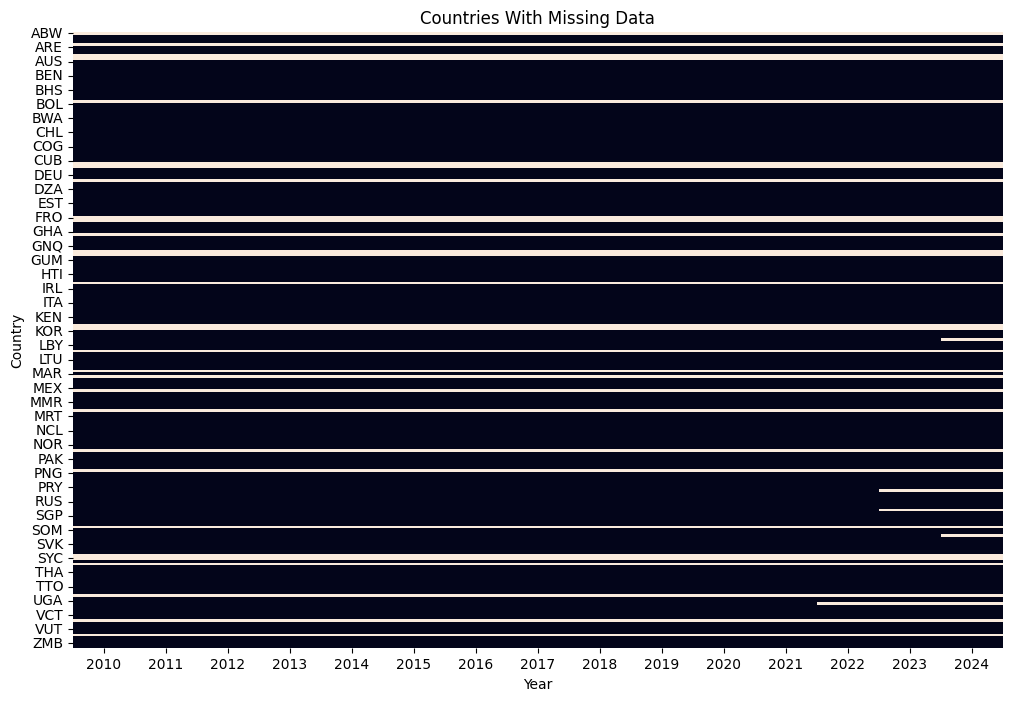

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    unemployment_matrix.isna(),
    cbar=False
)

plt.title("Countries With Missing Data")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

### Step 6.5 Filter Data with missing values

In [22]:
missing_by_country = unemployment_matrix.isna().sum(axis=1)

top30_missing_codes = (
    missing_by_country
    .sort_values(ascending=False)
    .head(30)
    .index
)

filtered_matrix = unemployment_matrix.drop(index=top30_missing_codes)

### Step 6.5 Visualise missing values before missing data correction

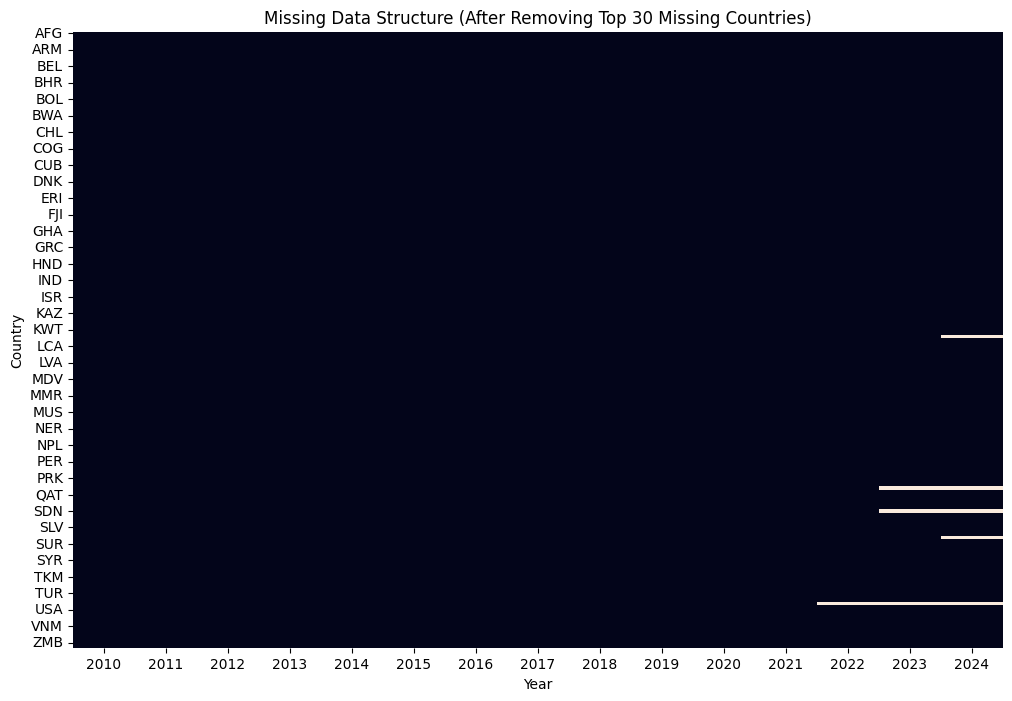

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    filtered_matrix.isna(),
    cbar=False
)

plt.title("Missing Data Structure (After Removing Top 30 Missing Countries)")
plt.xlabel("Year")
plt.ylabel("Country")

plt.show()

In [24]:
before_missing = unemployment_matrix.isna().sum().sum()
after_missing = filtered_matrix.isna().sum().sum()

print("Total missing values BEFORE cleaning:", before_missing)
print("Total missing values AFTER cleaning:", after_missing)

reduction = (before_missing - after_missing) / before_missing * 100
print("Reduction in missing data:", round(reduction,2), "%")

Total missing values BEFORE cleaning: 459
Total missing values AFTER cleaning: 9
Reduction in missing data: 98.04 %


### Handling missing Data 

- After removing countries with extensive missing observations, only five countries exhibited isolated missing values. These were imputed using linear interpolation across neighbouring years to preserve temporal continuity

### Step 6.6 Use Linear Interpolation for remaining missing values

In [25]:
filtered_matrix = filtered_matrix.interpolate(axis=1)
filtered_matrix = filtered_matrix.apply(
    lambda row: row.fillna(row.mean()),
    axis=1
)

total_missing = filtered_matrix.isna().sum().sum()

print("\nTotal missing cells remaining:", total_missing)


Total missing cells remaining: 0


### Step 6.6 Visualise missing values after Liner Interpolation

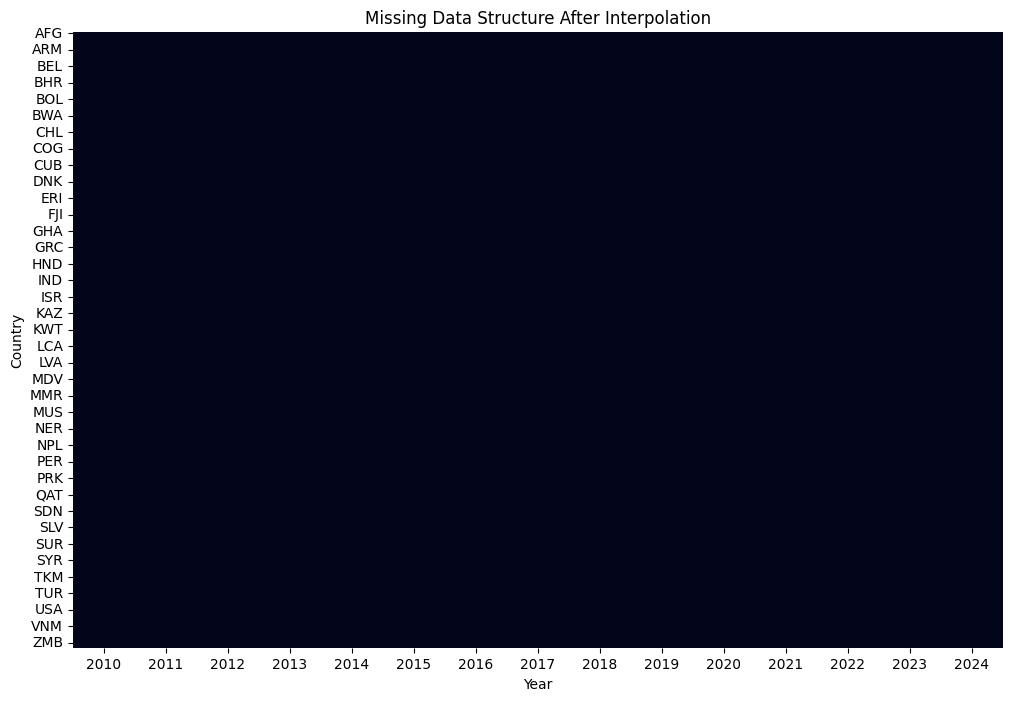

In [26]:
plt.figure(figsize=(12,8))

sns.heatmap(
    filtered_matrix.isna(),
    cbar=False
)

plt.title("Missing Data Structure After Interpolation")
plt.xlabel("Year")
plt.ylabel("Country")

plt.show()

## Step 7: Compute rank

### Why this is done
Rank shows how many independent directions are present a gives a numeric summary of matrix dimensionality. A rank substantially smaller than the number of years would indicate that unemployment patterns across countries are highly correlated over time, suggesting that a smaller set of latent economic factors drives global unemployment dynamics.

In [27]:
import numpy as np

rank = np.linalg.matrix_rank(filtered_matrix.values)

print("Matrix rank:", rank)
print("Number of years:", filtered_matrix.shape[1])
print("Number of countries:", filtered_matrix.shape[0])

Matrix rank: 15
Number of years: 15
Number of countries: 187


## Step 8: Compute REF and RREF on a subset

### Why this is done
- This is mainly pedagogical. It helps visualise pivot structure and row reduction. I have used a subset to demonstrate elimination process clearly, while avoiding large output that is easier to interpret


In [28]:
from sympy import Matrix

def compute_ref_rref(df, rows=15, cols=15, decimals=3):
    
    # create manageable subset
    subset = df.iloc[:rows, :cols].round(decimals)

    # convert to sympy matrix
    sym_matrix = Matrix(subset.values)

    # REF
    ref_matrix, ref_pivots = sym_matrix.echelon_form(with_pivots=True)

    # RREF
    rref_matrix, rref_pivots = sym_matrix.rref()

    return {
        "subset": subset,
        "ref_matrix": ref_matrix,
        "ref_pivots": ref_pivots,
        "rref_matrix": rref_matrix,
        "rref_pivots": rref_pivots
    }

In [29]:
ref_rref = compute_ref_rref(filtered_matrix)

print("Subset used for REF/RREF:")
print(ref_rref["subset"])

print("\nREF pivot columns:")
print(ref_rref["ref_pivots"])

print("\nRREF pivot columns:")
print(ref_rref["rref_pivots"])

print("\nREF matrix:")
print(ref_rref["ref_matrix"])

print("\nRREF matrix:")
print(ref_rref["rref_matrix"])

Subset used for REF/RREF:
year            2010    2011    2012    2013    2014    2015    2016    2017  \
country_code                                                                   
AFG            7.809   7.830   7.875   7.921   7.915   9.032  10.116  11.184   
AGO           16.595  16.770  16.539  16.464  16.372  16.472  16.572  16.617   
ALB           14.086  13.481  13.376  15.866  18.055  17.193  15.418  13.616   
ARE            2.798   2.587   2.323   2.125   1.999   1.793   1.640   2.462   
ARG            7.714   7.180   7.217   7.100   7.268   7.577   8.088   8.347   
ARM           19.523  18.884  17.511  16.576  17.498  18.261  17.617  17.704   
AUS            5.214   5.083   5.225   5.663   6.078   6.055   5.711   5.592   
AUT            4.883   4.637   4.909   5.367   5.674   5.802   6.064   5.561   
AZE            5.630   5.420   5.190   4.970   4.910   4.960   5.000   5.000   
BDI            1.615   1.602   1.593   1.584   1.572   1.449   1.352   1.250   
BEL           

## REF/RREFF Results
- Subset showw full column rank as show in Step 6. Columns are linearly independent

## Step 9: Correlation between years

### Why this is done
This step computes the correlation matrix between unemployment rates across different years to understand how similar the global unemployment structure is over time. Visualising the matrix helps identify strong relationships or structural shifts between years.

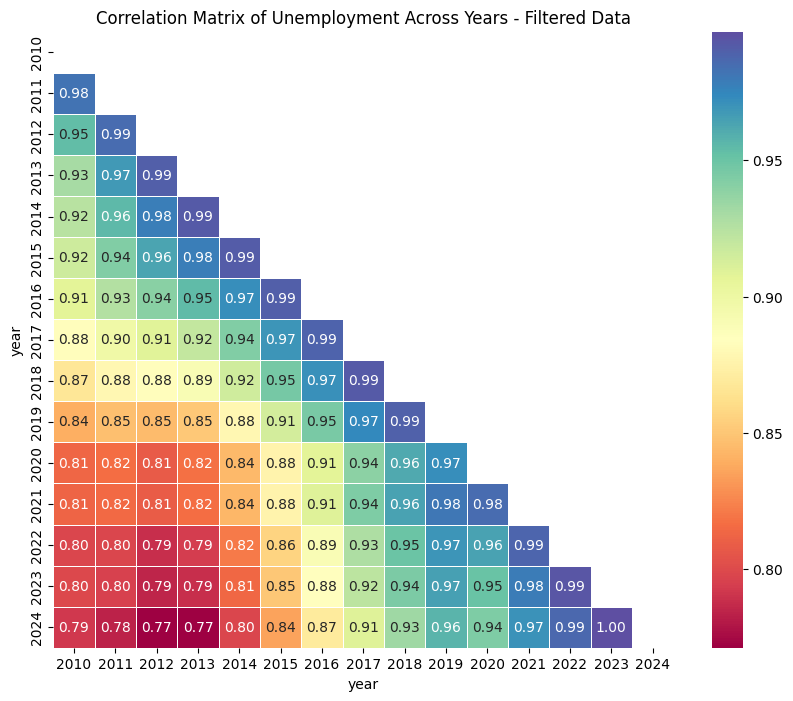

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = filtered_matrix.corr()

# mask the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="Spectral",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Unemployment Across Years - Filtered Data")
plt.show()

## Step 10: PCA on unemployment trajectories

### Why this is done
PCA finds the dominant orthogonal directions of variation.

### Step 10.1: Standardise Data

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(filtered_matrix)

### Step 10.2: Compute PCA

In [32]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

### Step 10.3: Calculate Explained Variance

In [33]:
explained_variance = pd.Series(
    pca_full.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))]
)

print(explained_variance)

PC1     0.910905
PC2     0.064107
PC3     0.012030
PC4     0.004940
PC5     0.003612
PC6     0.001502
PC7     0.000756
PC8     0.000568
PC9     0.000416
PC10    0.000371
PC11    0.000270
PC12    0.000209
PC13    0.000149
PC14    0.000094
PC15    0.000071
dtype: float64


### Step 10.4: PCA Loadings Step (how strongly each original variable (year) contributes to each principal component)

In [34]:
loadings = pd.DataFrame(
    pca_full.components_,
    columns=filtered_matrix.columns,
    index=[f"PC{i+1}" for i in range(len(pca_full.components_))]
)

print(loadings.head())

year      2010      2011      2012      2013      2014      2015      2016  \
PC1   0.249709  0.252956  0.253349  0.254410  0.258410  0.262865  0.265759   
PC2   0.272681  0.311943  0.338630  0.324561  0.268999  0.189196  0.098001   
PC3   0.565022  0.378820  0.112454 -0.099309 -0.212113 -0.289668 -0.309996   
PC4   0.341767  0.129610 -0.138129 -0.250400 -0.214143 -0.141560  0.023335   
PC5  -0.325341  0.023123  0.203108  0.321833  0.196308 -0.060378 -0.269784   

year      2017      2018      2019      2020      2021      2022      2023  \
PC1   0.266964  0.266344  0.263345  0.257093  0.258829  0.255723  0.254590   
PC2  -0.019005 -0.100375 -0.194176 -0.244760 -0.274537 -0.312541 -0.315732   
PC3  -0.298532 -0.225485 -0.129596 -0.047714  0.022695  0.137978  0.201774   
PC4   0.099128  0.215973  0.204907  0.528643  0.133656 -0.201688 -0.366028   
PC5  -0.334908 -0.266875 -0.180452  0.519968  0.324321  0.112884 -0.087763   

year      2024  
PC1   0.251768  
PC2  -0.331330  
PC3   0.265

### Step 10.5: Elbow Curve

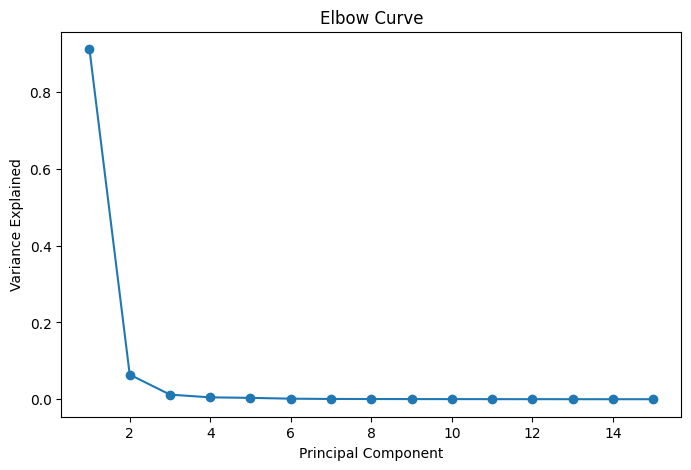

In [35]:
# Elbow Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Elbow Curve")

plt.show()

### Step 10.5: PCA Results

- The system of data has a low dimensionality, with 2 primary components PC1 (91%) and PC2 (6.5%) explaining approxiamtely 97.5% of unemployment variation. 

In [36]:
# PCA only for plotting
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Final clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

### Step 10.6: Create PCA DataFrame & map country names

In [37]:
cluster_df = pd.DataFrame({
    "country_code": filtered_matrix.index,
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "cluster": clusters
})

cluster_df["country"] = cluster_df["country_code"].map(country_map)

### Step 10.7: Visualise Countries clustered by PCA

In [38]:
import plotly.express as px

cluster_df = pd.DataFrame({
    "country_code": filtered_matrix.index,
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "cluster": clusters
})

cluster_df["country"] = cluster_df["country_code"].map(country_map)
cluster_df["cluster"] = cluster_df["cluster"].astype(str)

fig = px.scatter(
    cluster_df,
    x="PC1",
    y="PC2",
    color="cluster",
    hover_name="country",
    hover_data=["country_code", "cluster", "PC1", "PC2"],
    title="Countries Clustered in PCA Space",
    color_discrete_sequence=px.colors.qualitative.Dark2
)

fig.show()

### Step 10.7: Interpret PCA Clusters

- To make data more economically interpretable, I will determine the average unemployment per cluster. This will help differentiate which clusters represent high unemployment countries, stable labour markets and volatile economies. 

### Step 10.8: Map clusters back to Filtered Matrix

In [39]:
# Map clusters back to Filtered Matrix

clustered_data = filtered_matrix.copy()
clustered_data["cluster"] = clusters

### Step 10.9: Calculate average unemployment per cluster

In [40]:
cluster_means = clustered_data.groupby("cluster").mean()
cluster_means

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
cluster,,,,,,,,,,,,,,,
0,4.695679,4.524527,4.431063,4.422607,4.308446,4.278455,4.179348,4.011170,3.825973,3.803518,4.695152,4.443062,3.867509,3.657062,3.717375
1,11.171673,11.242769,11.512462,11.482135,11.200058,10.825115,10.519481,10.114173,9.735250,9.451212,10.783558,10.414404,9.139692,8.842327,8.772038
2,19.881913,20.137478,20.322391,20.544043,20.229913,20.489130,20.416565,20.100609,19.794609,19.312087,20.701522,20.470478,19.132087,18.243304,18.086000


### Step 10.10: Visualise unemployment across cluster (figure out which cluster is which)

In [41]:
import plotly.graph_objects as go

# descriptive labels for each cluster
cluster_labels = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
}

fig = go.Figure()

for cluster in cluster_means.index:
    fig.add_trace(
        go.Scatter(
            x=cluster_means.columns,
            y=cluster_means.loc[cluster],
            mode="lines+markers",
            name=cluster_labels[cluster]
        )
    )

fig.update_layout(
    title="Average Unemployment Trajectory by Cluster",
    xaxis_title="Year",
    yaxis_title="Unemployment Rate (%)",
    template="plotly_white"
)

fig.show()

# Print Countries in each cluster

cluster_descriptions = {
    "0": "High unemployment economies",
    "1": "Lower unemployment economies",
    "2": "Moderate unemployment economies",
}

for c in sorted(cluster_df["cluster"].unique()):
    countries = cluster_df.loc[cluster_df["cluster"] == c, "country"].tolist()
    print(f"\nCluster {c} - {cluster_descriptions[c]} ({len(countries)} countries):")
    print(", ".join(countries))



Cluster 0 - High unemployment economies (112 countries):
United Arab Emirates, Australia, Austria, Azerbaijan, Burundi, Belgium, Benin, Burkina Faso, Bangladesh, Bahrain, Belarus, Bolivia, Brunei Darussalam, Bhutan, Central African Republic, Canada, Switzerland, Channel Islands, China, Cote d'Ivoire, Cameroon, Congo, Dem. Rep., Comoros, Cuba, Czechia, Germany, Denmark, Dominican Republic, Ecuador, Eritrea, Ethiopia, Fiji, United Kingdom, Ghana, Guinea, Gambia, The, Guinea-Bissau, Guatemala, Hong Kong SAR, China, Honduras, Hungary, Indonesia, India, Iceland, Israel, Jamaica, Japan, Kazakhstan, Kenya, Kyrgyz Republic, Cambodia, Korea, Rep., Kuwait, Lao PDR, Liberia, Sri Lanka, Luxembourg, Macao SAR, China, Moldova, Madagascar, Maldives, Mexico, Mali, Malta, Myanmar, Mongolia, Mozambique, Mauritius, Malawi, Malaysia, Niger, Nigeria, Nicaragua, Netherlands, Norway, New Zealand, Oman, Pakistan, Panama, Peru, Philippines, Papua New Guinea, Poland, Korea, Dem. People's Rep., Paraguay, Qatar,

# Part 2: Multi-indicator matrix

## Step 11: Fetch all indicators

In [42]:
feature_cols = list(INDICATORS.keys())
raw_country_metadata = fetch_country_metadata()
country_metadata_df = country_metadata_to_dataframe(raw_country_metadata)

indicator_dataframes = {}

for feature_name, indicator_code in INDICATORS.items():
    print(f"\n=== {feature_name} | {indicator_code} ===")

    raw_rows = fetch_indicator_data(indicator_code, START_YEAR, END_YEAR)
    df_feature = raw_to_dataframe(raw_rows, feature_name)
    df_feature = merge_country_metadata(df_feature, country_metadata_df)
    df_feature = remove_aggregate_entities(df_feature)
    df_feature = df_feature.sort_values(["country_code", "year"]).reset_index(drop=True)

    indicator_dataframes[feature_name] = df_feature
    print(df_feature[["country", "country_code", "year", feature_name]].head())
    print("Shape:", df_feature.shape)

Fetched 296 country metadata rows

=== unemployment | SL.UEM.TOTL.ZS ===
Fetched 3990 raw rows for SL.UEM.TOTL.ZS
Removed 660 aggregate rows: Africa Eastern and Southern, Africa Western and Central, Arab World, Caribbean small states, Central Europe and the Baltics, Early-demographic dividend, East Asia & Pacific, East Asia & Pacific (IDA & IBRD countries), East Asia & Pacific (excluding high income), Euro area, Europe & Central Asia, Europe & Central Asia (IDA & IBRD countries), Europe & Central Asia (excluding high income), European Union, Fragile and conflict affected situations, Heavily indebted poor countries (HIPC), IBRD only, IDA & IBRD total, IDA blend, IDA only
... and 24 more.
  country country_code  year  unemployment
0   Aruba          ABW  2010           NaN
1   Aruba          ABW  2011           NaN
2   Aruba          ABW  2012           NaN
3   Aruba          ABW  2013           NaN
4   Aruba          ABW  2014           NaN
Shape: (3255, 10)

=== inflation | FP.CPI.TOTL

## Step 12: Build the merged panel dataset

### Why this is done
The multi-indicator matrix is built from a country-year panel first. After that, I can decide how to handle missing values before collapsing each country into one feature vector.

In [43]:
from src.data_processing import build_panel_dataset

panel_df = build_panel_dataset(indicator_dataframes)

print(panel_df.head())
print("Panel shape:", panel_df.shape)
print("\nMissing values by column:")
print(panel_df.isna().sum())

  country country_code  year  unemployment  inflation  gdp_growth  \
0   Aruba          ABW  2010           NaN   2.078141   -2.733457   
1   Aruba          ABW  2011           NaN   4.316297    3.369237   
2   Aruba          ABW  2012           NaN   0.627472   -1.040800   
3   Aruba          ABW  2013           NaN  -2.372065    6.431461   
4   Aruba          ABW  2014           NaN   0.421441    1.426099   

   life_expectancy  population_growth  
0           74.297           0.230041  
1           74.578           0.736689  
2           74.841           1.469782  
3           75.072           1.492031  
4           75.261           1.065512  
Panel shape: (3255, 8)

Missing values by column:
country                0
country_code           0
year                   0
unemployment         459
inflation            492
gdp_growth           130
life_expectancy        0
population_growth      1
dtype: int64


## Step 13: Check missing data and remove countries with complete indicator gaps

### Why this is done
For the multi-indicator matrix, a country should be removed only if at least one indicator is missing for every year. A country with a few missing years should stay in the dataset.


In [44]:
from src.data_processing import (
    summarise_country_feature_missingness,
    filter_countries_with_complete_indicator_gaps,
    interpolate_panel_by_country,
)

missing_detail = summarise_country_feature_missingness(panel_df, feature_cols)
missing_detail.head()

,country,country_code,unemployment,inflation,gdp_growth,life_expectancy,population_growth
0,Afghanistan,AFG,0,0,1,0,0
1,Albania,ALB,0,0,0,0,0
2,Algeria,DZA,0,0,0,0,0
3,American Samoa,ASM,15,15,2,0,0
4,Andorra,AND,15,15,0,0,0


### Step 13.1: Download metadata and check aggregates

In [45]:
panel_df_filtered, countries_removed, missing_detail = filter_countries_with_complete_indicator_gaps(
    panel_df,
    feature_cols,
)

print("Countries removed:", len(countries_removed))
display(countries_removed.head(20))

Countries removed: 40


,country,country_code,fully_missing_indicators
0,American Samoa,ASM,"[unemployment, inflation]"
1,Andorra,AND,"[unemployment, inflation]"
2,Antigua and Barbuda,ATG,[unemployment]
3,Aruba,ABW,[unemployment]
4,Bermuda,BMU,"[unemployment, inflation]"
5,British Virgin Islands,VGB,"[unemployment, inflation, gdp_growth]"
6,Cayman Islands,CYM,[unemployment]
7,Channel Islands,CHI,[inflation]
8,Cuba,CUB,[inflation]
9,Curacao,CUW,[unemployment]


### Step 13.2: Verify filtered Panel


In [46]:
print("Original panel shape:", panel_df.shape)
print("Filtered panel shape:", panel_df_filtered.shape)
print("\nRemaining missing values by column:")
print(panel_df_filtered[feature_cols].isna().sum().sort_values(ascending=False))

Original panel shape: (3255, 8)
Filtered panel shape: (2655, 8)

Remaining missing values by column:
inflation            77
gdp_growth           33
unemployment          9
life_expectancy       0
population_growth     0
dtype: int64


### Step 13.3: Interpolate only internal gaps within each country series

In [47]:
panel_df_interpolated = interpolate_panel_by_country(panel_df_filtered, feature_cols)

print("Missing values after interpolation:")
print(panel_df_interpolated[feature_cols].isna().sum().sort_values(ascending=False))

Missing values after interpolation:
inflation            72
gdp_growth           33
unemployment          9
life_expectancy       0
population_growth     0
dtype: int64


In [63]:
missing_entries = (
    panel_df_interpolated
    .melt(
        id_vars=["country_code", "year"],
        value_vars=feature_cols,
        var_name="indicator",
        value_name="value"
    )
    .query("value.isna()", engine="python")
    .sort_values(["country_code", "year"])
)

missing_country_indicator_years = (
    missing_entries
    .groupby(["country_code", "indicator"])["year"]
    .apply(list)
)

missing_country_indicator_years

country_code  indicator   
AFG           gdp_growth                                                 [2024]
ARG           inflation        [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
BTN           gdp_growth                                                 [2024]
COD           inflation        [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
DJI           gdp_growth                               [2010, 2011, 2012, 2013]
LBN           gdp_growth                                                 [2024]
              unemployment                                               [2024]
MMR           inflation                          [2020, 2021, 2022, 2023, 2024]
NCL           gdp_growth       [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
              inflation       [2010, 2017, 2018, 2019, 2020, 2021, 2022, 202...
PSE           unemployment                                         [2023, 2024]
SDN           inflation                                            [2023, 2024]
             

## Step 13.4: Handle missing data

- Countries with long or structurally unreliable missing runs were removed entirely from the panel, rather than heavily imputing multi-year gaps that could distort the final country-feature matrix.
- Short trailing gaps in the most recent period (2022 to 2024) were forward-filled within each country, on the assumption that these were more likely to reflect delayed reporting than major underlying shifts.
- A single isolated edge-case gap, Uzbekistan’s 2010 inflation value, was filled by interpolation so that one missing starting-year observation did not cause the country to be excluded unnecessarily.

In [65]:
# Clean remaining panel issues before building the final country-feature matrix

countries_to_remove = [
    "ARG", "COD", "NCL", "SSD", "TJK", "VEN",
    "YEM", "MMR", "SWZ", "SYR", "DJI", "UKR"
]

panel_df_final = panel_df_2024_filled.copy()

# 1. Remove selected countries entirely
panel_df_final = panel_df_final[
    ~panel_df_final["country_code"].isin(countries_to_remove)
].copy()

# 2. Forward-fill trailing gaps from 2022 to 2024 within each country
#    This only affects years 2022, 2023, 2024 after earlier years are used as history.
trailing_years = [2022, 2023, 2024]

for feature in feature_cols:
    for country_code, group_index in panel_df_final.groupby("country_code").groups.items():
        idx = list(group_index)
        country_df = panel_df_final.loc[idx].sort_values("year").copy()

        year_mask = country_df["year"].isin(trailing_years)
        country_df.loc[year_mask, feature] = country_df.loc[year_mask, feature].ffill()

        panel_df_final.loc[country_df.index, feature] = country_df[feature]

# 3. Interpolate UZB inflation for 2010
uzb_mask = panel_df_final["country_code"] == "UZB"
panel_df_final.loc[uzb_mask, "inflation"] = (
    panel_df_final.loc[uzb_mask]
    .sort_values("year")["inflation"]
    .interpolate(method="linear", limit_direction="both")
    .values
)

# Checks
print("Removed countries:")
print(sorted(countries_to_remove))

print("\nRemaining missing values by feature:")
print(panel_df_final[feature_cols].isna().sum().sort_values(ascending=False))

missing_entries_final = (
    panel_df_final
    .melt(
        id_vars=["country_code", "year"],
        value_vars=feature_cols,
        var_name="indicator",
        value_name="value"
    )
    .query("value.isna()", engine="python")
    .sort_values(["country_code", "indicator", "year"])
)

print("\nRemaining country-indicator-year gaps:")
print(
    missing_entries_final
    .groupby(["country_code", "indicator"])["year"]
    .apply(list)
)

Removed countries:
['ARG', 'COD', 'DJI', 'MMR', 'NCL', 'SSD', 'SWZ', 'SYR', 'TJK', 'UKR', 'VEN', 'YEM']

Remaining missing values by feature:
unemployment         0
inflation            0
gdp_growth           0
life_expectancy      0
population_growth    0
dtype: int64

Remaining country-indicator-year gaps:
Series([], Name: year, dtype: int64)


## Step 14: Build the country feature matrix


In [66]:
feature_matrix = (
    panel_df_final
    .groupby("country_code")[feature_cols]
    .mean()
    .sort_index()
)

feature_matrix.head()

,unemployment,inflation,gdp_growth,life_expectancy,population_growth
country_code,,,,,
AFG,10.504800,3.820777,1.501974,62.710200,2.933439
AGO,16.012667,18.143914,2.200475,61.636667,3.499049
ALB,13.341133,2.573963,2.937736,78.549733,-1.388415
ARE,2.458400,1.422577,3.248901,81.921667,3.289985
ARM,16.849933,3.580253,4.673333,74.907154,-0.071045


In [67]:
# Structure Check

print("Shape:", feature_matrix.shape)
print("Missing values:", feature_matrix.isna().sum().sum())

Shape: (165, 5)
Missing values: 0


## Step 14.1: Standardise Matrix

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

feature_matrix_scaled = scaler.fit_transform(feature_matrix)

import pandas as pd

feature_matrix_scaled = pd.DataFrame(
    feature_matrix_scaled,
    index=feature_matrix.index,
    columns=feature_matrix.columns
)

feature_matrix_scaled.head()

,unemployment,inflation,gdp_growth,life_expectancy,population_growth
country_code,,,,,
AFG,0.562518,-0.231103,-0.782292,-1.190511,1.342107
AGO,1.587681,1.172064,-0.451487,-1.326792,1.816373
ALB,1.090436,-0.353247,-0.102326,0.820257,-2.281780
ARE,-0.935134,-0.466042,0.045039,1.248312,1.641072
ARM,1.743519,-0.254666,0.719639,0.357846,-1.177161


## Step 14.2: Check Matrix Rank

In [69]:
import numpy as np

rank = np.linalg.matrix_rank(feature_matrix_scaled.values)

print("Matrix rank:", rank)
print("Number of indicators:", feature_matrix_scaled.shape[1])

Matrix rank: 5
Number of indicators: 5


## Step 14.3: Country similarity matrix

In [70]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(feature_matrix_scaled)

similarity_matrix = pd.DataFrame(
    similarity_matrix,
    index=feature_matrix.index,
    columns=feature_matrix.index
)

similarity_matrix.iloc[:5, :5]

country_code,AFG,AGO,ALB,ARE,ARM
country_code,,,,,
AFG,1.000000,0.805004,-0.593347,0.055464,-0.329235
AGO,0.805004,1.000000,-0.476402,-0.103869,-0.068265
ALB,-0.593347,-0.476402,1.000000,-0.576988,0.805067
ARE,0.055464,-0.103869,-0.576988,1.000000,-0.565765
ARM,-0.329235,-0.068265,0.805067,-0.565765,1.000000


## Step 14.4: Output for similar countries

In [73]:
target_country = "ZWE"

similarity_matrix[target_country].sort_values(ascending=False).head(10)

country_code
ZWE    1.000000
SDN    0.852348
IRN    0.813120
EGY    0.766647
LBN    0.759990
SUR    0.734368
MWI    0.682095
TUR    0.678807
GHA    0.603582
SLE    0.554550
Name: ZWE, dtype: float64

## Step 15: PCA

In [74]:
from sklearn.decomposition import PCA

pca = PCA()

principal_components = pca.fit_transform(feature_matrix_scaled)

explained_variance = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(feature_cols))]
)

explained_variance

PC1    0.352078
PC2    0.253969
PC3    0.164783
PC4    0.137525
PC5    0.091644
dtype: float64

## Step 15.1: Check PCA Loadings

In [75]:
loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=[f"PC{i+1}" for i in range(len(feature_cols))]
)

loadings

,unemployment,inflation,gdp_growth,life_expectancy,population_growth
PC1,-0.344631,0.180791,0.412069,-0.556644,0.607364
PC2,0.474553,0.663475,-0.457668,-0.348041,0.063308
PC3,0.745376,-0.471213,0.340929,-0.323902,0.035047
PC4,0.071308,0.514564,0.686647,0.083977,-0.501601
PC5,0.308803,0.200745,0.181721,0.676055,0.611776


## Step 15.2: Project countries into PCA Space

In [76]:
pca_scores = pd.DataFrame(
    principal_components,
    index=feature_matrix.index,
    columns=[f"PC{i+1}" for i in range(len(feature_cols))]
)

pca_scores.head()

,PC1,PC2,PC3,PC4,PC5
country_code,,,,,
AFG,0.919838,0.970958,0.694125,-1.389141,0.001374
AGO,1.320441,2.314475,0.970610,-0.616211,0.857751
ALB,-2.324289,-0.100007,0.598701,1.039152,-0.594177
ARE,0.558441,-1.104162,-0.808881,-0.993898,1.473752
ARM,-1.264529,0.130003,1.507761,1.107939,0.139818


In [89]:
import plotly.express as px
import pandas as pd

plot_df = pca_scores.reset_index().rename(columns={"index": "country_code"})

feature_df = feature_matrix.reset_index().rename(columns={"index": "country_code"})
plot_df = plot_df.merge(feature_df, on="country_code", how="left")

country_regions = (
    indicator_dataframes["unemployment"][["country_code", "region"]]
    .drop_duplicates()
)

plot_df = plot_df.merge(country_regions, on="country_code", how="left")

fig = px.scatter(
    plot_df,
    x="PC1",
    y="PC2",
    color="region",
    hover_name="country_code",
    hover_data={
        "unemployment": ":.2f",
        "inflation": ":.2f",
        "gdp_growth": ":.2f",
        "life_expectancy": ":.2f",
        "population_growth": ":.2f",
        "PC1": ":.2f",
        "PC2": ":.2f",
        "region": True
    },
    title="Interactive PCA map of countries by region",
    width=1200,
    height=800
)

fig.update_traces(marker=dict(size=9))
fig.show()

## Part 3: Predict next-year downturn risk

In [96]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 642.3 kB/s  0:00:04 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [98]:
import platform
print(platform.architecture())

('64bit', '')


In [99]:
import numpy as np
import pandas as pd


from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


## Step 16.1: Build the modelling dataset

In [100]:
# Keep only the columns needed for modelling
model_df = panel_df_final[
    [
        "country_code",
        "year",
        "unemployment",
        "inflation",
        "gdp_growth",
        "life_expectancy",
        "population_growth",
    ]
].copy()

model_df = model_df.sort_values(["country_code", "year"]).reset_index(drop=True)

# Create next-year targets within each country
model_df["unemployment_next_year"] = (
    model_df.groupby("country_code")["unemployment"].shift(-1)
)

model_df["gdp_growth_next_year"] = (
    model_df.groupby("country_code")["gdp_growth"].shift(-1)
)

# Binary target: next-year downturn risk
# 1 = next year's GDP growth is negative
# 0 = next year's GDP growth is zero or positive
model_df["downturn_risk_next_year"] = (
    model_df["gdp_growth_next_year"] < 0
).astype(int)

# Create lag features within each country
base_features = [
    "unemployment",
    "inflation",
    "gdp_growth",
    "life_expectancy",
    "population_growth",
]

for col in base_features:
    model_df[f"{col}_lag1"] = model_df.groupby("country_code")[col].shift(1)
    model_df[f"{col}_lag2"] = model_df.groupby("country_code")[col].shift(2)

# Optional change features
model_df["unemployment_change_1y"] = model_df["unemployment"] - model_df["unemployment_lag1"]
model_df["inflation_change_1y"] = model_df["inflation"] - model_df["inflation_lag1"]
model_df["gdp_growth_change_1y"] = model_df["gdp_growth"] - model_df["gdp_growth_lag1"]

# Drop rows where lags or next-year target are unavailable
model_df = model_df.dropna().reset_index(drop=True)

print("Modelling dataset shape:", model_df.shape)
print(model_df.head())
print("\nClass balance:")
print(model_df["downturn_risk_next_year"].value_counts(normalize=True).rename("proportion"))

Modelling dataset shape: (1980, 23)
  country_code  year  unemployment  inflation  gdp_growth  life_expectancy  \
0          AFG  2012         7.875   6.441213   12.752287           61.735   
1          AFG  2013         7.921   7.385772    5.600745           62.188   
2          AFG  2014         7.915   4.673996    2.724543           62.260   
3          AFG  2015         9.032  -0.661709    1.451315           62.270   
4          AFG  2016        10.116   4.383892    2.260314           62.646   

   population_growth  unemployment_next_year  gdp_growth_next_year  \
0           4.047863                   7.921              5.600745   
1           3.418227                   7.915              2.724543   
2           3.632519                   9.032              1.451315   
3           3.119959                  10.116              2.260314   
4           2.535720                  11.184              2.647003   

   downturn_risk_next_year  ...  inflation_lag2  gdp_growth_lag1  \
0     

## Step 16.2: Define Features and target

In [101]:
feature_cols_model = [
    "unemployment",
    "inflation",
    "gdp_growth",
    "life_expectancy",
    "population_growth",
    "unemployment_lag1",
    "inflation_lag1",
    "gdp_growth_lag1",
    "life_expectancy_lag1",
    "population_growth_lag1",
    "unemployment_lag2",
    "inflation_lag2",
    "gdp_growth_lag2",
    "life_expectancy_lag2",
    "population_growth_lag2",
    "unemployment_change_1y",
    "inflation_change_1y",
    "gdp_growth_change_1y",
]

X = model_df[feature_cols_model].copy()
y = model_df["downturn_risk_next_year"].copy()

# Keep metadata for interpretation
meta = model_df[["country_code", "year"]].copy()

## Step 16.3: Train/Test Helper function

In [102]:
def evaluate_classifier_cv(name, model, X, y, meta, n_splits=5):
    """
    Evaluate a classifier using time-based cross-validation.
    Assumes rows are globally sorted by year after preprocessing.
    """
    eval_df = pd.concat([meta, X, y.rename("target")], axis=1).sort_values(["year", "country_code"]).reset_index(drop=True)

    X_sorted = eval_df[X.columns]
    y_sorted = eval_df["target"]
    meta_sorted = eval_df[["country_code", "year"]]

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_results = []
    confusion_matrices = []
    all_predictions = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_sorted), start=1):
        X_train, X_test = X_sorted.iloc[train_idx], X_sorted.iloc[test_idx]
        y_train, y_test = y_sorted.iloc[train_idx], y_sorted.iloc[test_idx]
        meta_test = meta_sorted.iloc[test_idx].copy()

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # Use probabilities if available for ROC-AUC
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = y_pred

        fold_accuracy = accuracy_score(y_test, y_pred)
        fold_precision = precision_score(y_test, y_pred, zero_division=0)
        fold_recall = recall_score(y_test, y_pred, zero_division=0)

        # ROC-AUC only valid if both classes exist in y_test
        if y_test.nunique() == 2:
            fold_roc_auc = roc_auc_score(y_test, y_score)
        else:
            fold_roc_auc = np.nan

        cm = confusion_matrix(y_test, y_pred)

        fold_results.append({
            "model": name,
            "fold": fold,
            "accuracy": fold_accuracy,
            "precision": fold_precision,
            "recall": fold_recall,
            "roc_auc": fold_roc_auc,
            "test_size": len(test_idx),
            "positive_rate_test": y_test.mean(),
        })

        confusion_matrices.append({
            "model": name,
            "fold": fold,
            "confusion_matrix": cm
        })

        preds_fold = meta_test.copy()
        preds_fold["y_true"] = y_test.values
        preds_fold["y_pred"] = y_pred
        preds_fold["y_score"] = y_score
        preds_fold["model"] = name
        preds_fold["fold"] = fold
        all_predictions.append(preds_fold)

    results_df = pd.DataFrame(fold_results)
    predictions_df = pd.concat(all_predictions, ignore_index=True)

    summary_df = pd.DataFrame({
        "model": [name],
        "accuracy_mean": [results_df["accuracy"].mean()],
        "precision_mean": [results_df["precision"].mean()],
        "recall_mean": [results_df["recall"].mean()],
        "roc_auc_mean": [results_df["roc_auc"].mean()],
    })

    return results_df, summary_df, confusion_matrices, predictions_df

## Step 16.4: Define models

In [117]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=600,
        max_depth=12,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
}

## Step 16.5: Model Evaluation

In [118]:
all_fold_results = []
all_summaries = []
all_confusions = {}
all_predictions = []

for model_name, model in models.items():
    fold_df, summary_df, confusion_list, preds_df = evaluate_classifier_cv(
        name=model_name,
        model=model,
        X=X,
        y=y,
        meta=meta,
        n_splits=5
    )

    all_fold_results.append(fold_df)
    all_summaries.append(summary_df)
    all_confusions[model_name] = confusion_list
    all_predictions.append(preds_df)

fold_results_df = pd.concat(all_fold_results, ignore_index=True)
summary_results_df = pd.concat(all_summaries, ignore_index=True).sort_values(
    "roc_auc_mean", ascending=False
)
predictions_df = pd.concat(all_predictions, ignore_index=True)

print("Cross-validation summary:")
print(summary_results_df)

Cross-validation summary:
               model  accuracy_mean  precision_mean  recall_mean  roc_auc_mean
1      Random Forest       0.774545        0.467161     0.208418      0.692743
2  Gradient Boosting       0.755758        0.431450     0.255456      0.659668
0      Decision Tree       0.686667        0.275367     0.477929      0.640134


## Step 16.6: Model Metrics

In [119]:
fold_results_df.sort_values(["model", "fold"])

,model,fold,accuracy,precision,recall,roc_auc,test_size,positive_rate_test
0,Decision Tree,1,0.803030,0.187500,0.257143,0.572930,330,0.106061
1,Decision Tree,2,0.836364,0.274194,0.653846,0.791118,330,0.078788
2,Decision Tree,3,0.551515,0.560606,0.237179,0.533875,330,0.472727
3,Decision Tree,4,0.484848,0.107345,0.612903,0.545798,330,0.093939
4,Decision Tree,5,0.757576,0.247191,0.628571,0.756949,330,0.106061
10,Gradient Boosting,1,0.906061,0.700000,0.200000,0.702421,330,0.106061
11,Gradient Boosting,2,0.890909,0.272727,0.230769,0.751898,330,0.078788
12,Gradient Boosting,3,0.557576,0.857143,0.076923,0.618479,330,0.472727
13,Gradient Boosting,4,0.615152,0.119048,0.483871,0.568886,330,0.093939
14,Gradient Boosting,5,0.809091,0.208333,0.285714,0.656659,330,0.106061


## Model Results Summary

In [120]:
summary_results_df.round(3)

,model,accuracy_mean,precision_mean,recall_mean,roc_auc_mean
1,Random Forest,0.775,0.467,0.208,0.693
2,Gradient Boosting,0.756,0.431,0.255,0.660
0,Decision Tree,0.687,0.275,0.478,0.640


In [121]:
for model_name, confusion_list in all_confusions.items():
    print(f"\n=== {model_name} ===")
    for item in confusion_list:
        print(f"\nFold {item['fold']}")
        print(item["confusion_matrix"])


=== Decision Tree ===

Fold 1
[[256  39]
 [ 26   9]]

Fold 2
[[259  45]
 [  9  17]]

Fold 3
[[145  29]
 [119  37]]

Fold 4
[[141 158]
 [ 12  19]]

Fold 5
[[228  67]
 [ 13  22]]

=== Random Forest ===

Fold 1
[[294   1]
 [ 34   1]]

Fold 2
[[297   7]
 [ 20   6]]

Fold 3
[[171   3]
 [140  16]]

Fold 4
[[187 112]
 [ 17  14]]

Fold 5
[[284  11]
 [ 27   8]]

=== Gradient Boosting ===

Fold 1
[[292   3]
 [ 28   7]]

Fold 2
[[288  16]
 [ 20   6]]

Fold 3
[[172   2]
 [144  12]]

Fold 4
[[188 111]
 [ 16  15]]

Fold 5
[[257  38]
 [ 25  10]]


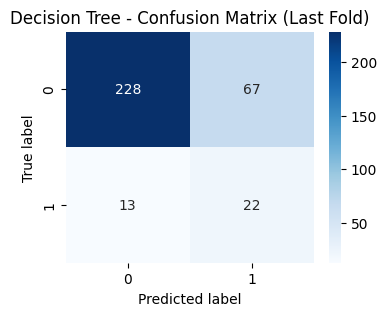

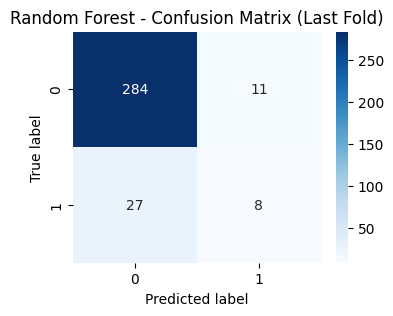

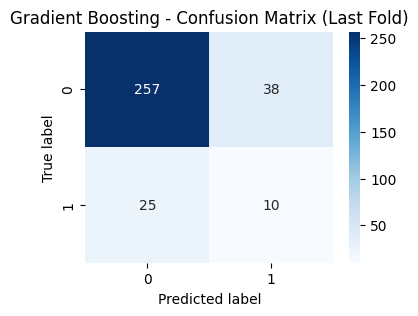

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, confusion_list in all_confusions.items():
    cm = confusion_list[-1]["confusion_matrix"]

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix (Last Fold)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

In [123]:
rf_model = models["Random Forest"]
rf_model.fit(X, y)

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols_model
).sort_values(ascending=False)

rf_importance.head(15)

gdp_growth                0.126771
gdp_growth_change_1y      0.081371
inflation_lag1            0.067251
gdp_growth_lag2           0.064331
gdp_growth_lag1           0.061333
unemployment_change_1y    0.058457
inflation_lag2            0.055568
inflation_change_1y       0.054584
inflation                 0.054038
unemployment              0.045782
unemployment_lag1         0.043669
population_growth_lag2    0.042396
population_growth         0.042385
life_expectancy_lag2      0.041601
unemployment_lag2         0.040681
dtype: float64